# Starting tests to model 2025wny

## Drive setup and imports

In [1]:
drive = False
NERSC = True

if drive:
    from google.colab import drive
    drive.mount('/content/drive')
    base_dir = '/content/drive/MyDrive/repos/GL-PS'
if NERSC:
    base_dir = '/global/u1/o/osoler/repos/GL-PS'

import os
import sys

os.chdir(base_dir)
%ls

modeling/  notebooks/  README.md  src/  test.txt


In [2]:
!nvidia-smi
# When running from google drive
if drive:
    !pip install corner
    !pip install lenstronomy==1.13.2
    !pip install gigalens --no-deps

# When running on NERSC
if NERSC:
    gigalens_base_dir = '/global/u1/o/osoler/gigalens/src'
    if gigalens_base_dir not in sys.path:
        sys.path.append(gigalens_base_dir)
        #print(sys.path)

Fri Feb  6 09:31:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:03:00.0 Off |                    0 |
| N/A   30C    P0             53W /  400W |       1MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [11]:
# import modeling functions
from importlib import reload
import src.flux_ratios_pipeline_funcs
reload(src.flux_ratios_pipeline_funcs)
from src.flux_ratios_pipeline_funcs import *

# import gigalens functions
from gigalens.tf.inference import ModellingSequence
from gigalens.tf.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.tf.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.tf.profiles.light import sersic
from gigalens.tf.profiles.mass import sis, shear, epl, sie
from tensorflow_probability import distributions as tfd, bijectors as tfb

flux_ratios_pipeline_funcs.py version: 0.3.1


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDirectionArrows
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.visualization.wcsaxes import add_scalebar
from astropy.stats import sigma_clipped_stats



## Observational data



In [5]:

data_dir = base_dir + '/modeling/2025wny/data/'
psfr_path = 'nirc2_psf_psfr_stacked.npy'
psf_path = 'nirc2_psf_stacked.npy'
image_fits = 'nirc2_wny_full.fits'
image_fits_clean = 'nirc2_wny_full_clean.fits'
psf_photutil_path = 'wny_photutil_psf_fit.csv'

with fits.open(data_dir + image_fits) as hdul:
  heads = hdul[0].header
  data = hdul[0].data
  hdul.close()

  heads_clean = hdul[0].header
  heads_list = ['CD1_1', 'CD1_2', 'CD2_1', 'CD2_2']
  for hl in heads_list:
    heads_clean[hl] = float(heads[hl])
  heads_clean['RADESYSa'] = heads['RADECSYS']
wcs = WCS(heads_clean)

psfr = np.load(data_dir + psfr_path)
psf = np.load(data_dir + psf_path)
psf_photutil = pd.read_csv(data_dir + psf_photutil_path)


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-BEG to 60990.630833 from DATE-BEG.
Set MJD-END to 60990.632953 from DATE-END'. [astropy.wcs.wcs]


In [6]:
psf_photutil

,Unnamed: 0,x_fit,y_fit,flux_fit,x_err,y_err,flux_err
0,0,491.346959,624.391736,60.829975,0.041131,0.045180,0.686246
1,1,433.149259,411.246418,17.631145,0.085960,0.094008,0.412534
2,2,634.350728,333.624255,14.024787,0.118965,0.131048,0.457709
3,3,884.289485,600.654906,8.869229,0.156156,0.172022,0.379112


SKy mean: -8.86e-02, sky median: -8.88e-02, sky std: 4.88e-02


Text(0.5, 1.0, 'psf')

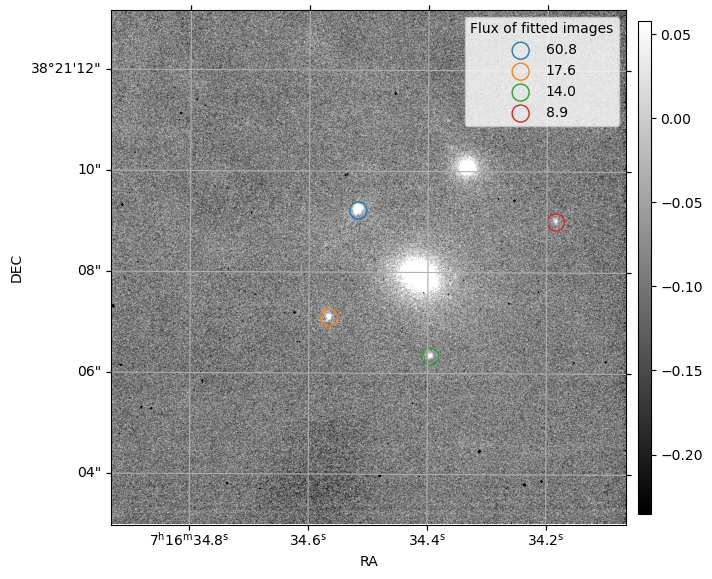

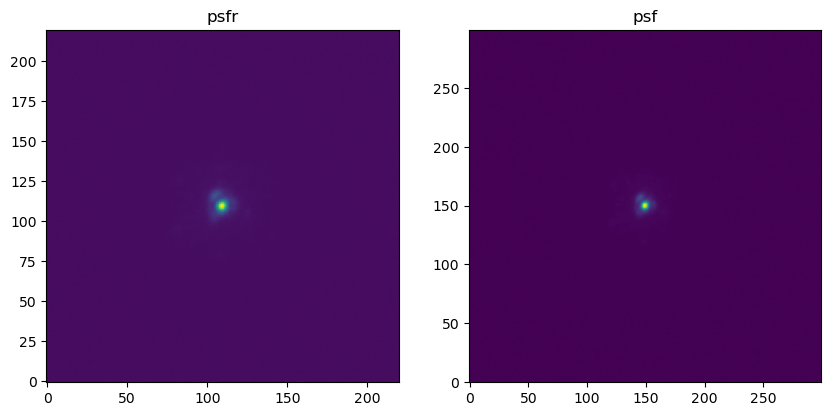

In [7]:
pixel_fit = np.array([psf_photutil['y_fit'].values, psf_photutil['x_fit'].values]).T
pixscale = 0.009952 # arcsec/px
exptime = 180

sky_mean, sky_median, sky_std = sigma_clipped_stats(data, sigma=3.0, maxiters=5)
print('SKy mean: %.2e, sky median: %.2e, sky std: %.2e'%(sky_mean, sky_median, sky_std))
bkg_rms = sky_std

stretch = 'linear'
percent = (5,99)
vminmax = (sky_mean - 3*sky_std,sky_mean + 3*sky_std)
# norm
norm = simple_norm(data, stretch,
                   #min_percent=percent[0], max_percent=percent[1],
                   #vmin = vminmax[0], vmax = vminmax[1])
                   min_cut = vminmax[0], max_cut = vminmax[1])
# figure
fig, ax = plt.subplots(1,1, figsize=(8,8))
fog, ax2 = plt.subplots(1,2, figsize=(10,5))
ax = [ax, ax2[0], ax2[1]]
ax[0].remove()
ax[0] = fig.add_subplot(1,1,1,projection=wcs)
im = ax[0].imshow(data, cmap='gray', origin = 'lower', norm = norm)
plt.colorbar(im, ax = ax[0],
             fraction = 0.15, aspect = 40, shrink = 0.8, pad = 0.02)
# images
for i in range(len(psf_photutil)):
  phot_row = psf_photutil.iloc[i]
  ax[0].scatter(phot_row['x_fit'], phot_row['y_fit'], label = '%.1f'%phot_row['flux_fit'],
             marker = 'o', s  = 150,
             facecolor = 'none', edgecolors=plt.get_cmap('tab10')(i), alpha = 1)
ax[0].legend(title = 'Flux of fitted images')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('DEC')
ax[0].grid()
# psfs
ax[1].imshow(psfr, origin = 'lower')
ax[1].set_title('psfr')

ax[2].imshow(psf, origin = 'lower')
ax[2].set_title('psf')

2026-02-06 09:33:52.405002: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
2026-02-06 09:33:52.407427: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38366 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
2026-02-06 09:33:52.410448: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 38366 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0
2026-02-06 09:33:52.413414: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 38366 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bu

[[625 491]
 [495 611]
 [709 709]]


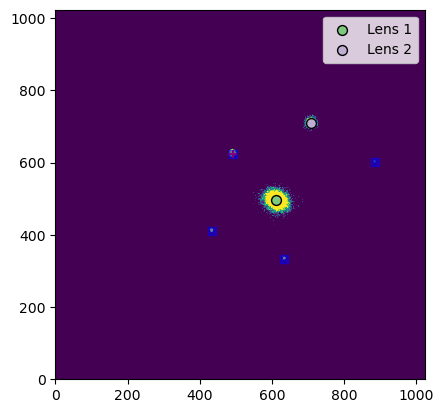

In [8]:
bp_converter = BrightestPoints(number_of_images = 3, num_pixels = data.shape[0],
                             grid_size = 50, delta_pix = pixscale,
                             supersample = 1)
bp_px = bp_converter.find_brightest_points(data)
print(bp_px.numpy())
plt.imshow(data, origin = 'lower', vmin=0, vmax = 0.1)
plt.scatter(bp_px[:,1], bp_px[:,0], c = 'r', marker='+')
plt.scatter(psf_photutil['x_fit'], psf_photutil['y_fit'], c = 'b', marker='s', alpha = 0.5)

lens1_px = bp_px[1]
lens2_px = bp_px[2]
pixel_lens = np.array([lens1_px, lens2_px])
for i, len_px in enumerate([lens1_px, lens2_px]):
  plt.scatter(len_px[1], len_px[0], marker='o', alpha = 1, s = 50, linewidths=1,
              edgecolors='black', facecolor = plt.get_cmap('Accent')(i), label = 'Lens %d'%(i+1))
plt.legend()

In [9]:

bp_converter = BrightestPoints(number_of_images = 4, num_pixels = data.shape[0],
                             grid_size = 20, delta_pix = pixscale,
                             supersample = 1)
x_arcsec, y_arcsec = bp_converter.pix_to_arcsec(pixel_fit)
x_arcsec_lens, y_arcsec_lens = bp_converter.pix_to_arcsec(pixel_lens)
print(x_arcsec, y_arcsec)

print(x_arcsec_lens, y_arcsec_lens)

flux_truth_test = tf.constant(psf_photutil['flux_fit'], dtype=tf.float32)
print(flux_truth_test)

tf.Tensor([-0.20401621 -0.78123224  1.2191198   3.70712   ], shape=(4,), dtype=float32) tf.Tensor([ 1.1195998  -1.0001762  -1.7764323   0.88075185], shape=(4,), dtype=float32)
tf.Tensor([0.9902238 1.9655199], shape=(2,), dtype=float32) tf.Tensor([-0.1642082  1.9655199], shape=(2,), dtype=float32)
tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)


# Model



In [12]:
xy_lens_1 = tf.constant([x_arcsec_lens[0].numpy(), y_arcsec_lens[0].numpy()], dtype=tf.float32)
xy_lens_2 = (x_arcsec_lens[1].numpy(), y_arcsec_lens[1].numpy())

# Uniform prior
lens_prior_uniform = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 1, high = 3),
          gamma=tfd.Uniform(1.5, 3,),
          e1=tfd.Uniform(-0.1, 0.1),
          e2=tfd.Uniform(-0.1, 0.1),
          center_x=tfd.Uniform(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Uniform(xy_lens_1[1]-0.2, xy_lens_1[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Uniform(-0.1, 0.3),
           gamma2=tfd.Uniform(-0.1, 0.3),
          ),),])

# Normal distribution prior
lens_prior_norm = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 1, high = 3),
          gamma=tfd.TruncatedNormal(2, 0.5, 1, 3), # bounds between 1 and 3, mean at 2, std of 0.5
          e1=tfd.Normal(0, 0.1),
          e2=tfd.Normal(0, 0.1),
          center_x=tfd.Normal(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Normal(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Normal(0.1, 0.2),
           gamma2=tfd.Normal(0.1, 0.2),
          ),),])

# physical model
phys_model = PhysicalModel(
    [ # mass profile
        epl.EPL(50), # 50 is the maximum number of iterations for calculating the deflection
        shear.Shear() # External shear model, parameterized by shear components ``gamma1`` and ``gamma2``
    ],
    [ # lens light
        sersic.SersicEllipse(), # defined by e1, e2 and center_x, center_y
    ],
    [ # source light (Point() defined in functions)
        Point()
    ]
)

# truth configuration list
truth_test = [
    [ # mass distribution
        {'theta_E': 2.0, 'gamma': 1.4, 'e1': 0.02, 'e2': 0.002, 'center_x': 1.17, 'center_y': 0.05},
        {'gamma1': 0.06, 'gamma2': 0.04}  # external shear
    ],
    [ # lensing galaxy light
        {'R_sersic': 0.350, 'n_sersic': 2.586, 'e1': -0.262, 'e2': 0.239, 'center_x': 0.011, 'center_y': -0.05, 'Ie': 250.055}
    ],
    [ # source light
        {'center_x': 1.17, 'center_y': 0.05, 'Ie': 2815.973}
    ]
]

Choosing a prior, creating the probabilistic model

In [13]:
lens_prior_chosen = lens_prior_uniform
prior = tfd.JointDistributionSequential([lens_prior_chosen,])
# resolution
supersample = 1
num_pix = data.shape[0]
# prob model without observed image
prob_model = ForwardProbModel(prior, 0, background_rms=bkg_rms, exp_time=exptime)
# example of sampling from the prob model
example1 = lens_prior_chosen.sample(seed = 1)
example2 = lens_prior_chosen.sample(seed = 2)
example3 = lens_prior_chosen.sample(seed = 3)
print('Sample parameters')
for ex in [example1, example2, example3]:
    print('-----------------')
    print_formatted_dict(ex)

# size = int(tf.size(tf.nest.flatten(example)))
# kernel = np.load('/content/drive/MyDrive/point-source-updates/F475W-epsf.npy').astype(np.float32)
sim_config = SimulatorConfig(delta_pix=pixscale, num_pix=num_pix, supersample=supersample)

lens_sim = LensSimulator(phys_model, sim_config, bs=1)


Sample parameters
-----------------
 - theta_E   :    2.159240
   gamma     :    1.738230
   e2        :    0.044558
   e1        :    0.036768
   center_y  :   -0.287475
   center_x  :    0.862560
 - gamma2    :   -0.070352
   gamma1    :   -0.082135
-----------------
 - theta_E   :    2.935602
   gamma     :    1.731808
   e2        :    0.078100
   e1        :    0.014694
   center_y  :   -0.114032
   center_x  :    1.057679
 - gamma2    :    0.150283
   gamma1    :    0.127424
-----------------
 - theta_E   :    1.771553
   gamma     :    2.263635
   e2        :   -0.068169
   e1        :   -0.050824
   center_y  :   -0.342870
   center_x  :    0.861316
 - gamma2    :    0.288826
   gamma1    :    0.103792


2026-02-06 09:40:57.855693: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x5574afa87be0


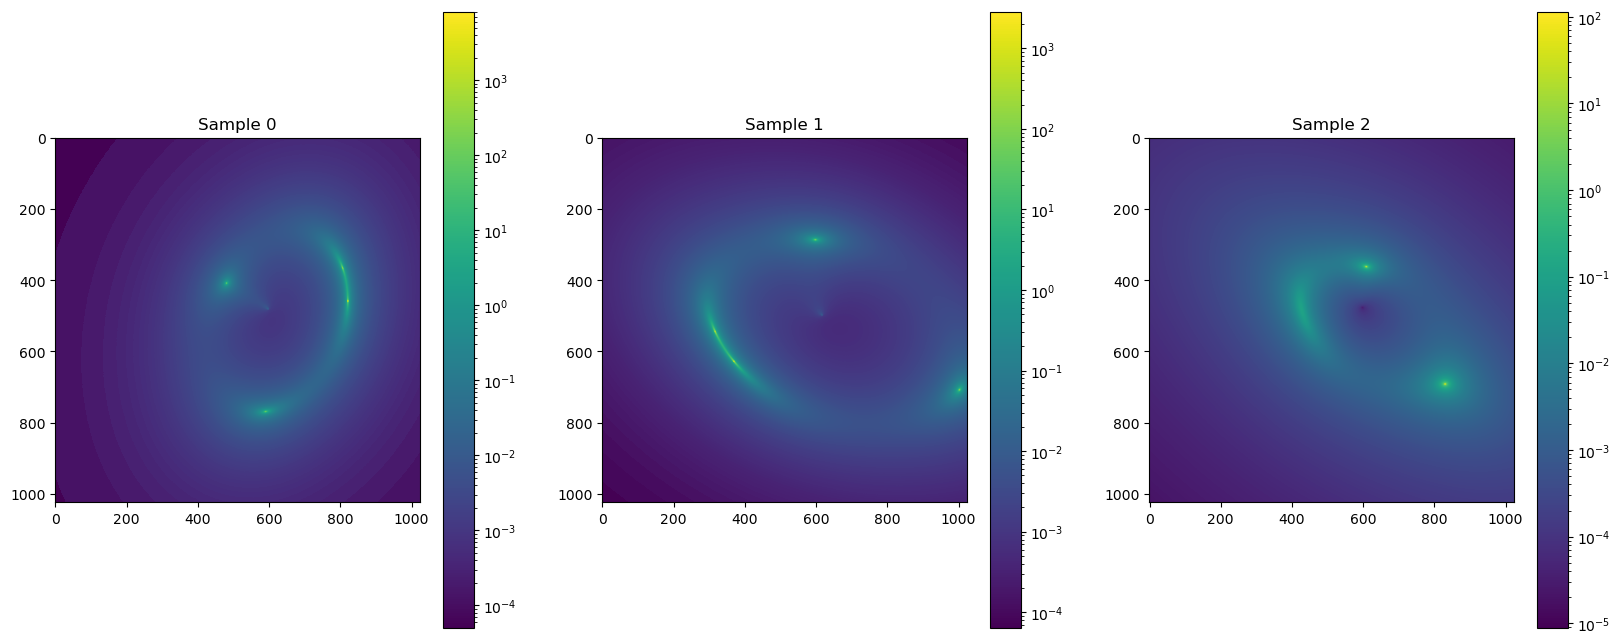

In [14]:
# simulated image with example of sampled mass distribution and truth source light
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
for i, ex in enumerate([example1, example2, example3]):
  sim_image = lens_sim.simulate([ex, [], truth_test[2]])
  im = ax[i].imshow(sim_image, norm = 'log')#, vmin=0, vmax=10)
  plt.colorbar(im, ax = ax[i])
  ax[i].set_title('Sample %i'%i)



    ============== weight_dist = 1.00e+02 | weight_flux = 1.00e+02 ==============


--- Modeling a real system ----


  0%|          | 0/1000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----


2026-02-06 09:41:19.870423: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fc160004b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-06 09:41:19.870447: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-02-06 09:41:19.870454: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-02-06 09:41:19.870459: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-02-06 09:41:19.870463: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (3): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-02-06 09:41:19.882743: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-06 09:4


Best parameters:
 - theta_E   :    2.054827
   gamma     :    1.711637
   e2        :    0.012475
   e1        :    0.116794
   center_y  :   -0.060960
   center_x  :    1.305723
 - gamma2    :    0.053044
   gamma1    :    0.151701


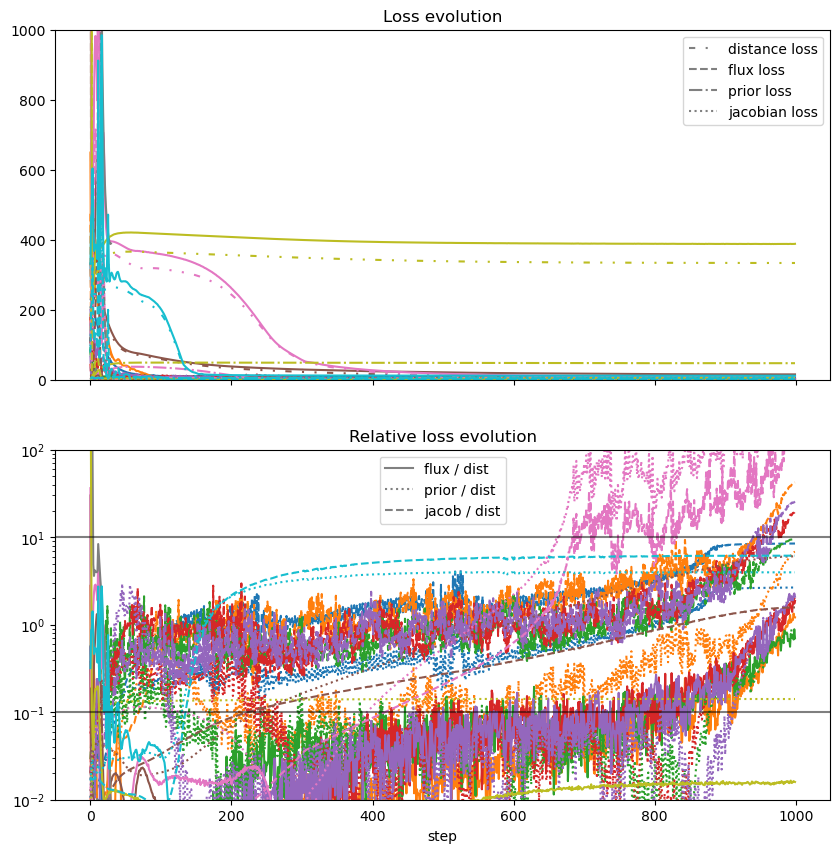


----- real system. comparing flux ratio difference ----


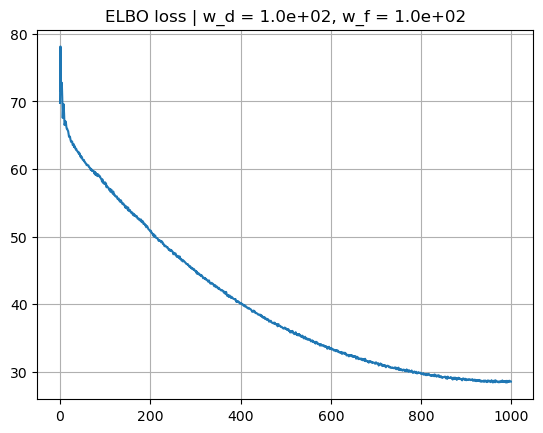


----- real system. comparing flux ratio difference ----


2026-02-06 09:42:12.383506: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:105] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. sanitize_seed/seed
2026-02-06 09:42:24.810584: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local memory in function 'fusion_300', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_281', 4 bytes spill stores, 8 bytes spill loads




----------------method: adaptative------------------



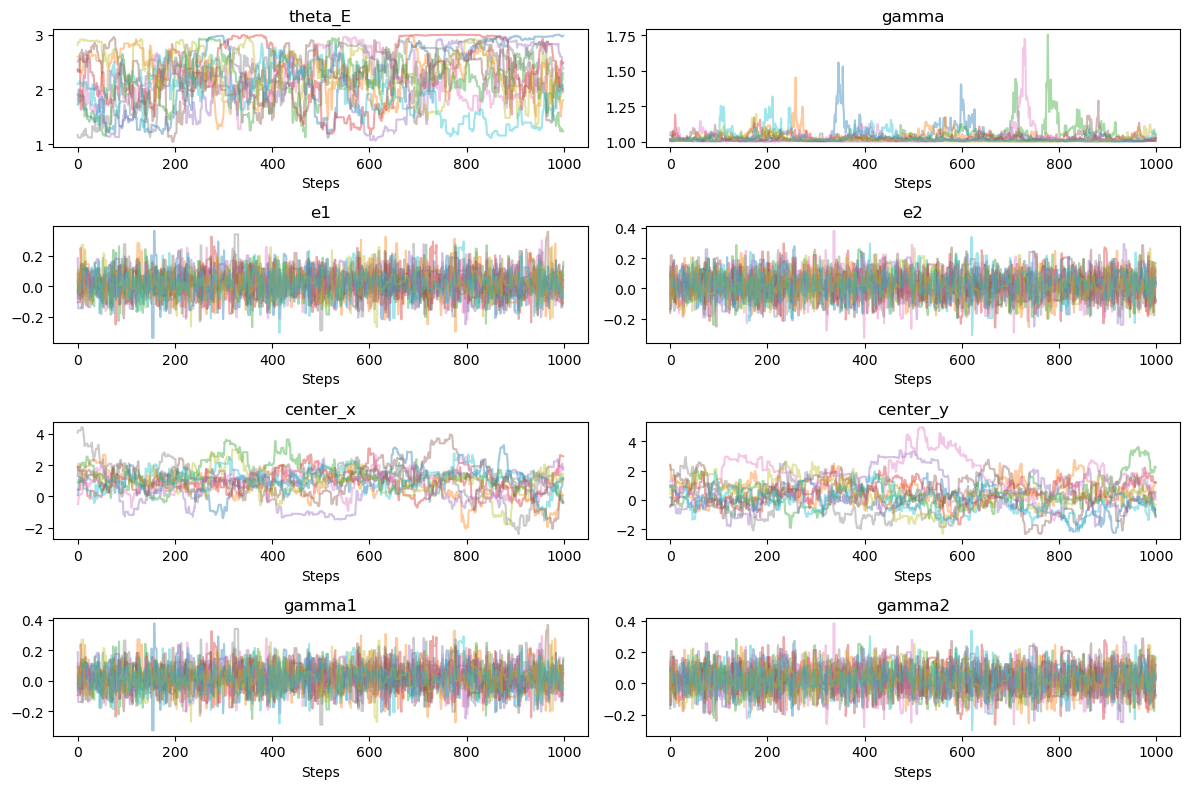


Rhat:
theta_E   :   1.165045
gamma     :   1.159853
e2        :   1.002828
e1        :   1.003184
center_y  :   1.131831
center_x  :   1.178274
gamma2    :   1.002731
gamma1    :   1.003200

ESS:
theta_E   :     3564.3
gamma     :     3760.1
e2        :   133945.9
e1        :   119186.9
center_y  :     4521.9
center_x  :     3577.7
gamma2    :   135407.7
gamma1    :   121043.2


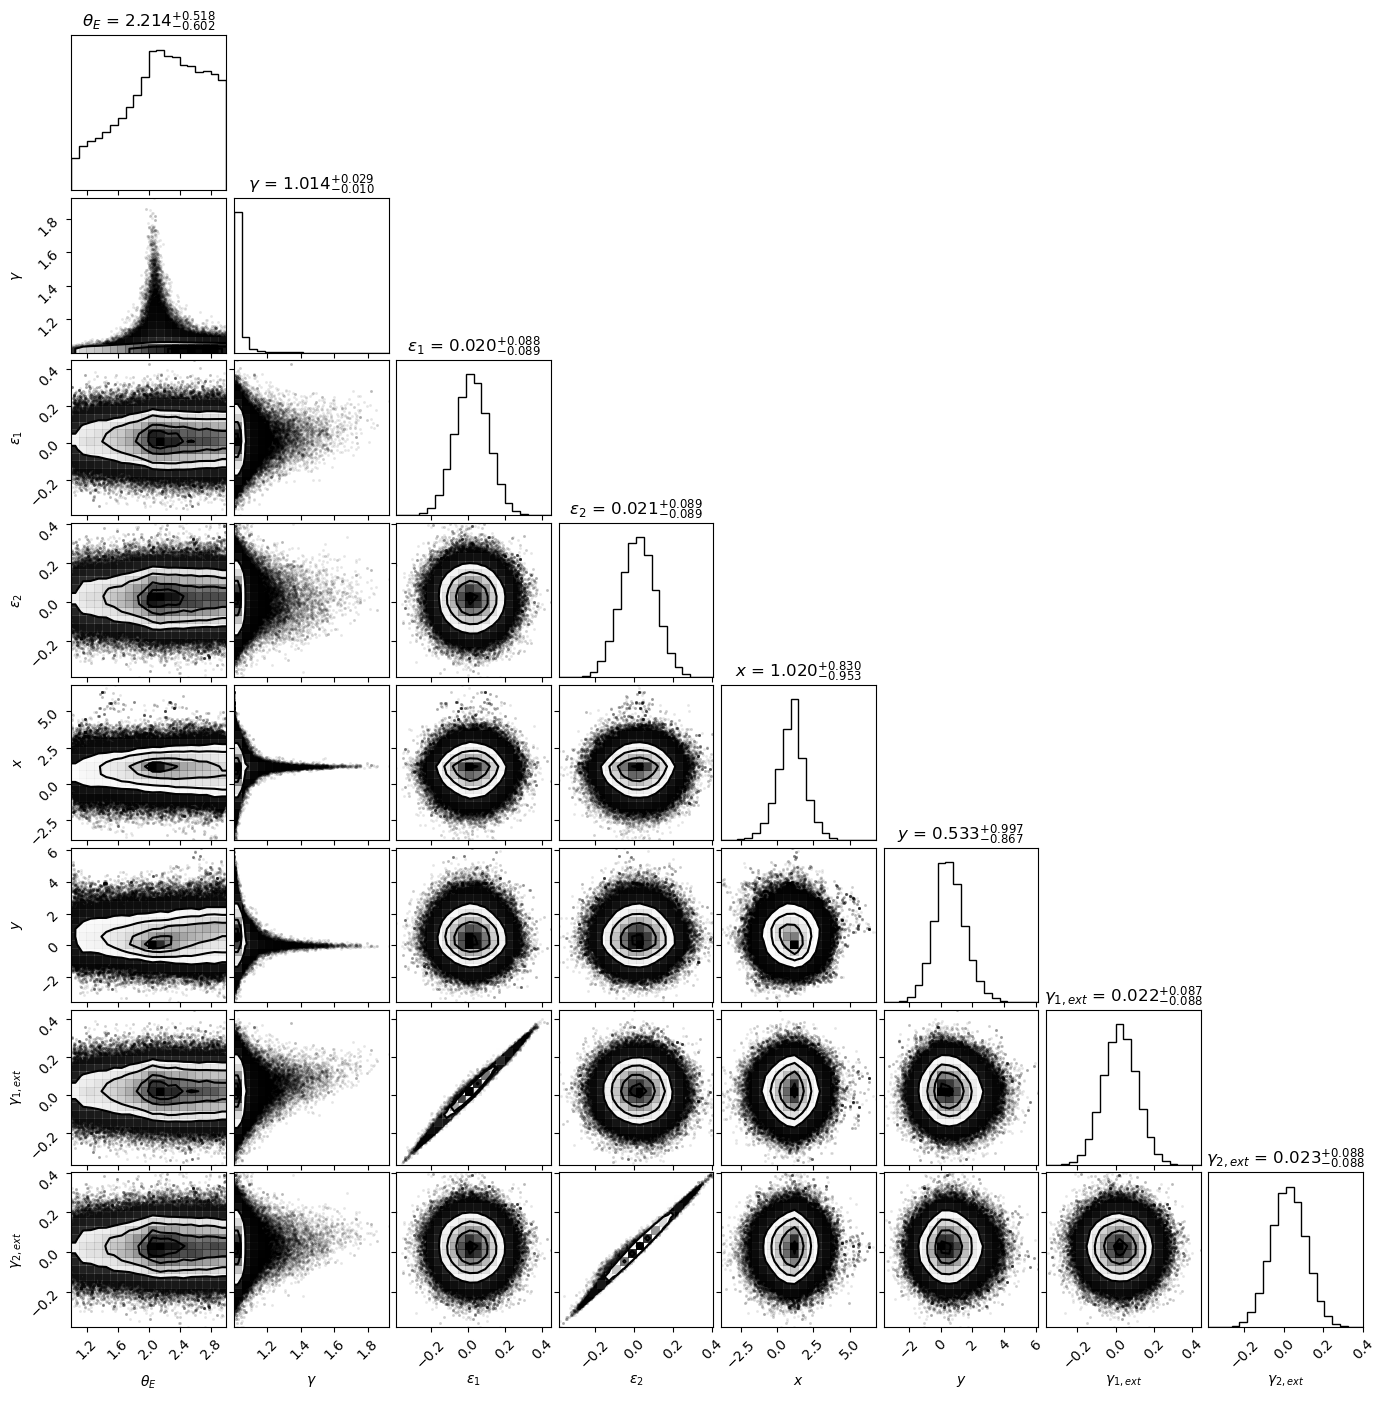

Parameter  |     Mean |   Median
--------------------------------
theta_E    |   2.1757 |   2.2137
gamma      |   1.0265 |   1.0139
e1         |   0.0201 |   0.0202
e2         |   0.0208 |   0.0206
center_x   |   0.9756 |   1.0203
center_y   |   0.5845 |   0.5326
gamma1     |   0.0222 |   0.0224
gamma2     |   0.0234 |   0.0234


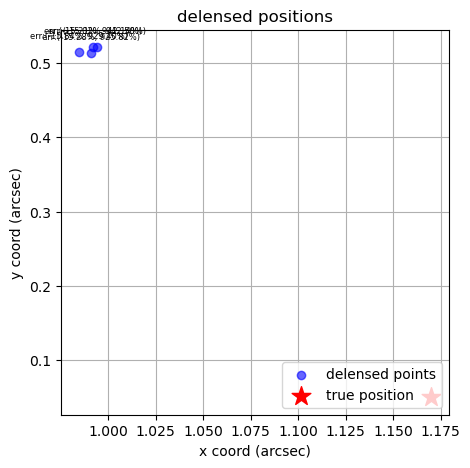

self.prob_model_output
 - theta_E   :    2.213709
   gamma     :    1.013877
   e2        :    0.020625
   e1        :    0.020187
   center_y  :    0.532583
   center_x  :    1.020254
 - gamma2    :    0.023372
   gamma1    :    0.022421


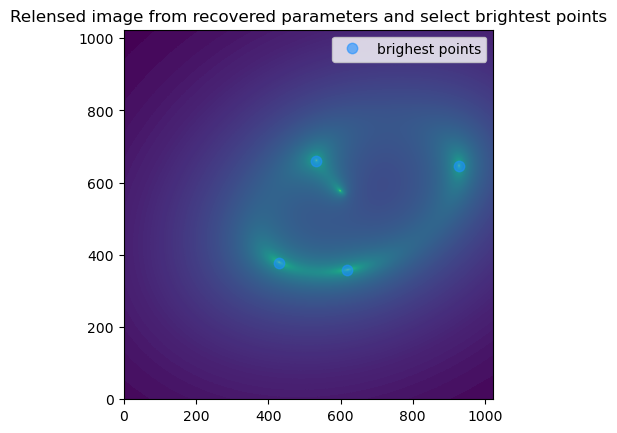

Brighest points reshaped into x, y:

x: [[ 0.2040158]
 [-0.8210402]
 [ 1.0598879]
 [ 4.135056 ]]

y: [[ 1.4778719]
 [-1.3285923]
 [-1.5375843]
 [ 1.3285918]]

Kwargs lens
 - theta_E   :    2.213709
   gamma     :    1.013877
   e1        :    0.020187
   e2        :    0.020625
   center_x  :    1.020254
   center_y  :    0.532583
 - gamma1    :    0.022421
   gamma2    :    0.023372


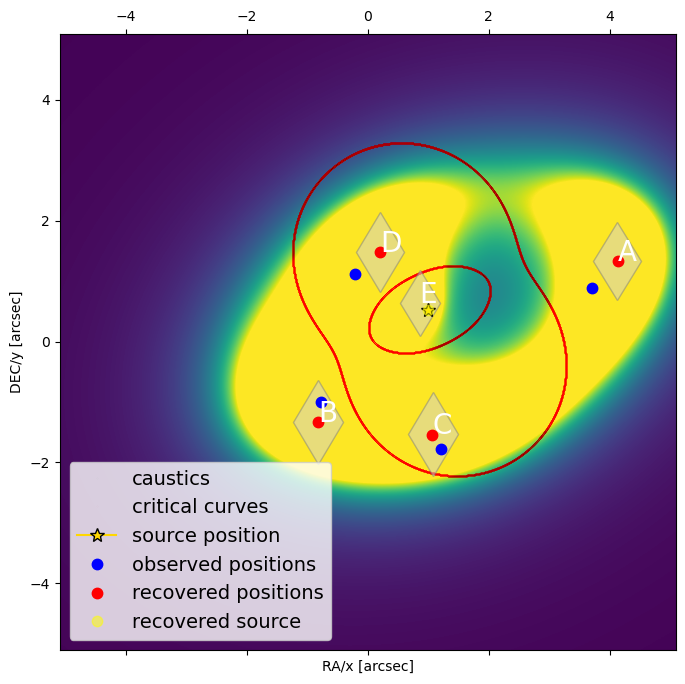


----- flux ratio errors -----
la mag del input tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)

loss terms (in observed positions):
 [[3.7420032e-09]
 [1.2866609e-08]
 [2.0210631e-08]
 [8.1623819e-09]
 [1.2771902e-08]
 [1.3515744e-10]]

flux ratios observed:
 [[3.450143 ]
 [4.337319 ]
 [6.858542 ]
 [1.2571418]
 [1.9879007]
 [1.5812861]]

flux ratios recovered (in observed positions):
 [[2.29622   ]
 [0.36963704]
 [0.62618047]
 [0.16097632]
 [0.27270055]
 [1.6940415 ]]

relative errors (in observed positions):
flux1/flux2: 33.45%
flux1/flux3: 91.48%
flux1/flux4: 90.87%
flux2/flux3: 87.20%
flux2/flux4: 86.28%
flux3/flux4: 7.13%

observed_magnifications SN Zicky: tf.Tensor([0.5199572  0.2799297  0.24966455 0.19854167], shape=(4,), dtype=float32)

Predicted magnifications (in recovered positions). The ordering may have changed:
 [[ -8102.404]
 [ 36368.2  ]
 [-38691.215]
 [ 11575.296]]

Predicted magnifications (in observed positions):
 [[-17560.479]
 [ 1158

  0%|          | 0/1000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----

Best parameters:
 - theta_E   :    2.055813
   gamma     :    1.635297
   e2        :    0.008406
   e1        :    0.116637
   center_y  :   -0.065768
   center_x  :    1.303313
 - gamma2    :    0.046220
   gamma1    :    0.149111


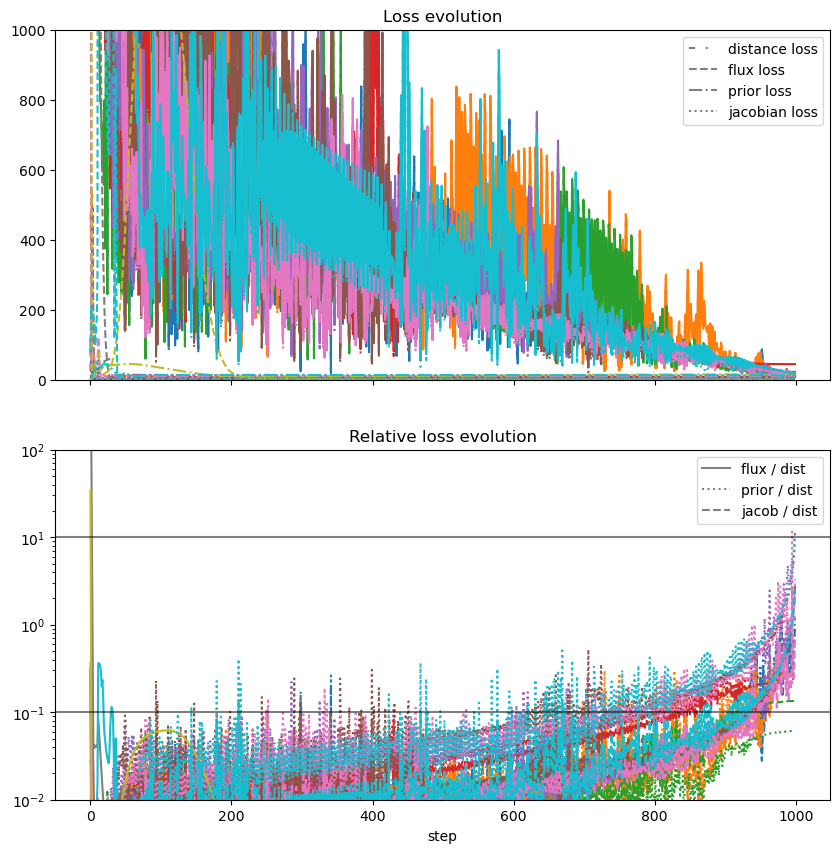


----- real system. comparing flux ratio difference ----


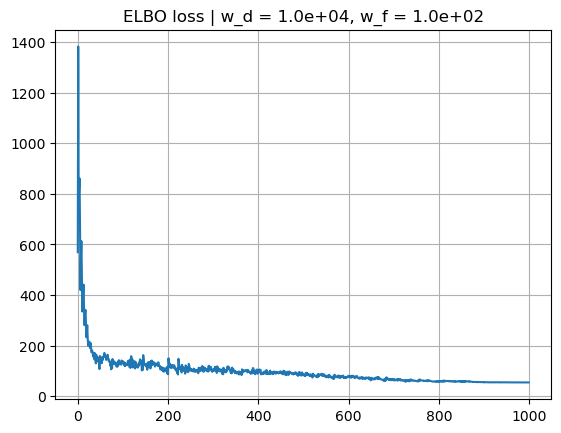


----- real system. comparing flux ratio difference ----


2026-02-06 09:50:23.674323: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local memory in function 'fusion_300', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_281', 4 bytes spill stores, 8 bytes spill loads




----------------method: adaptative------------------



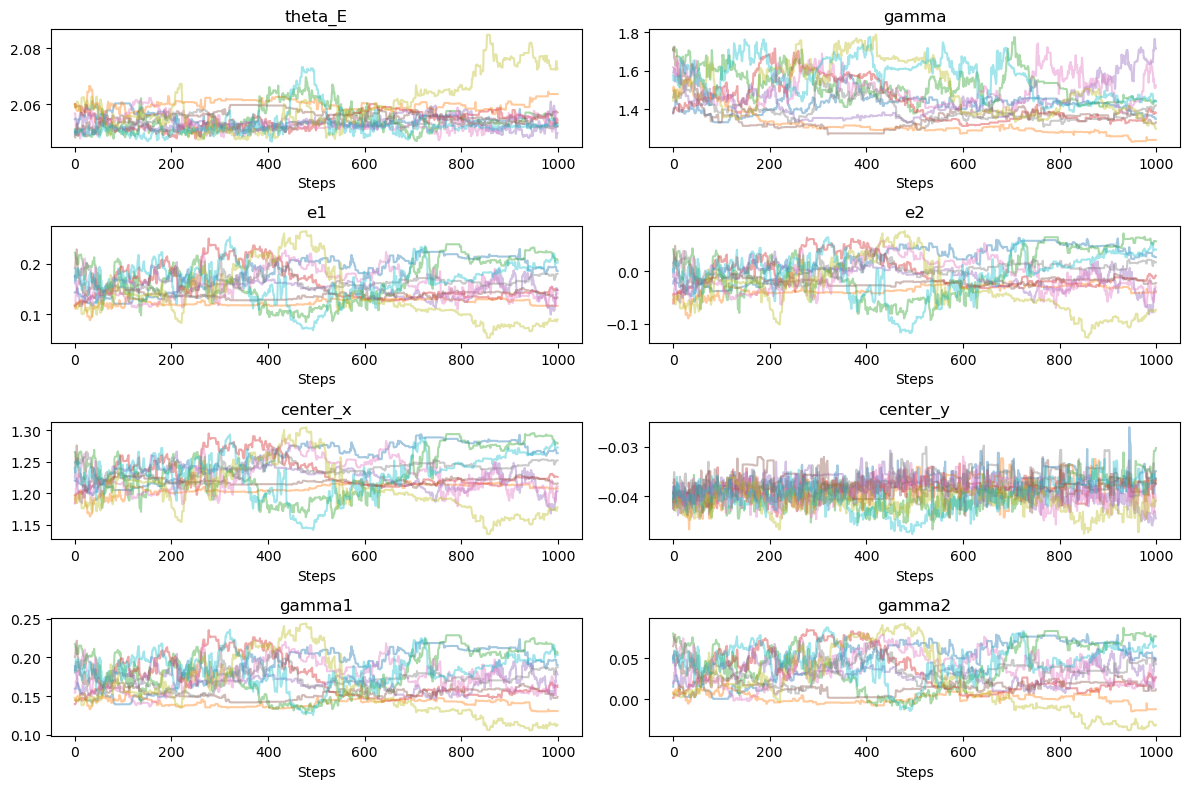


Rhat:
theta_E   :   2.072896
gamma     :   1.928993
e2        :   2.017370
e1        :   2.025648
center_y  :   1.512579
center_x  :   2.031673
gamma2    :   2.156056
gamma1    :   2.126518

ESS:
theta_E   :      966.1
gamma     :     1038.2
e2        :      991.5
e1        :      987.5
center_y  :     1474.5
center_x  :      984.7
gamma2    :      932.6
gamma1    :      943.9


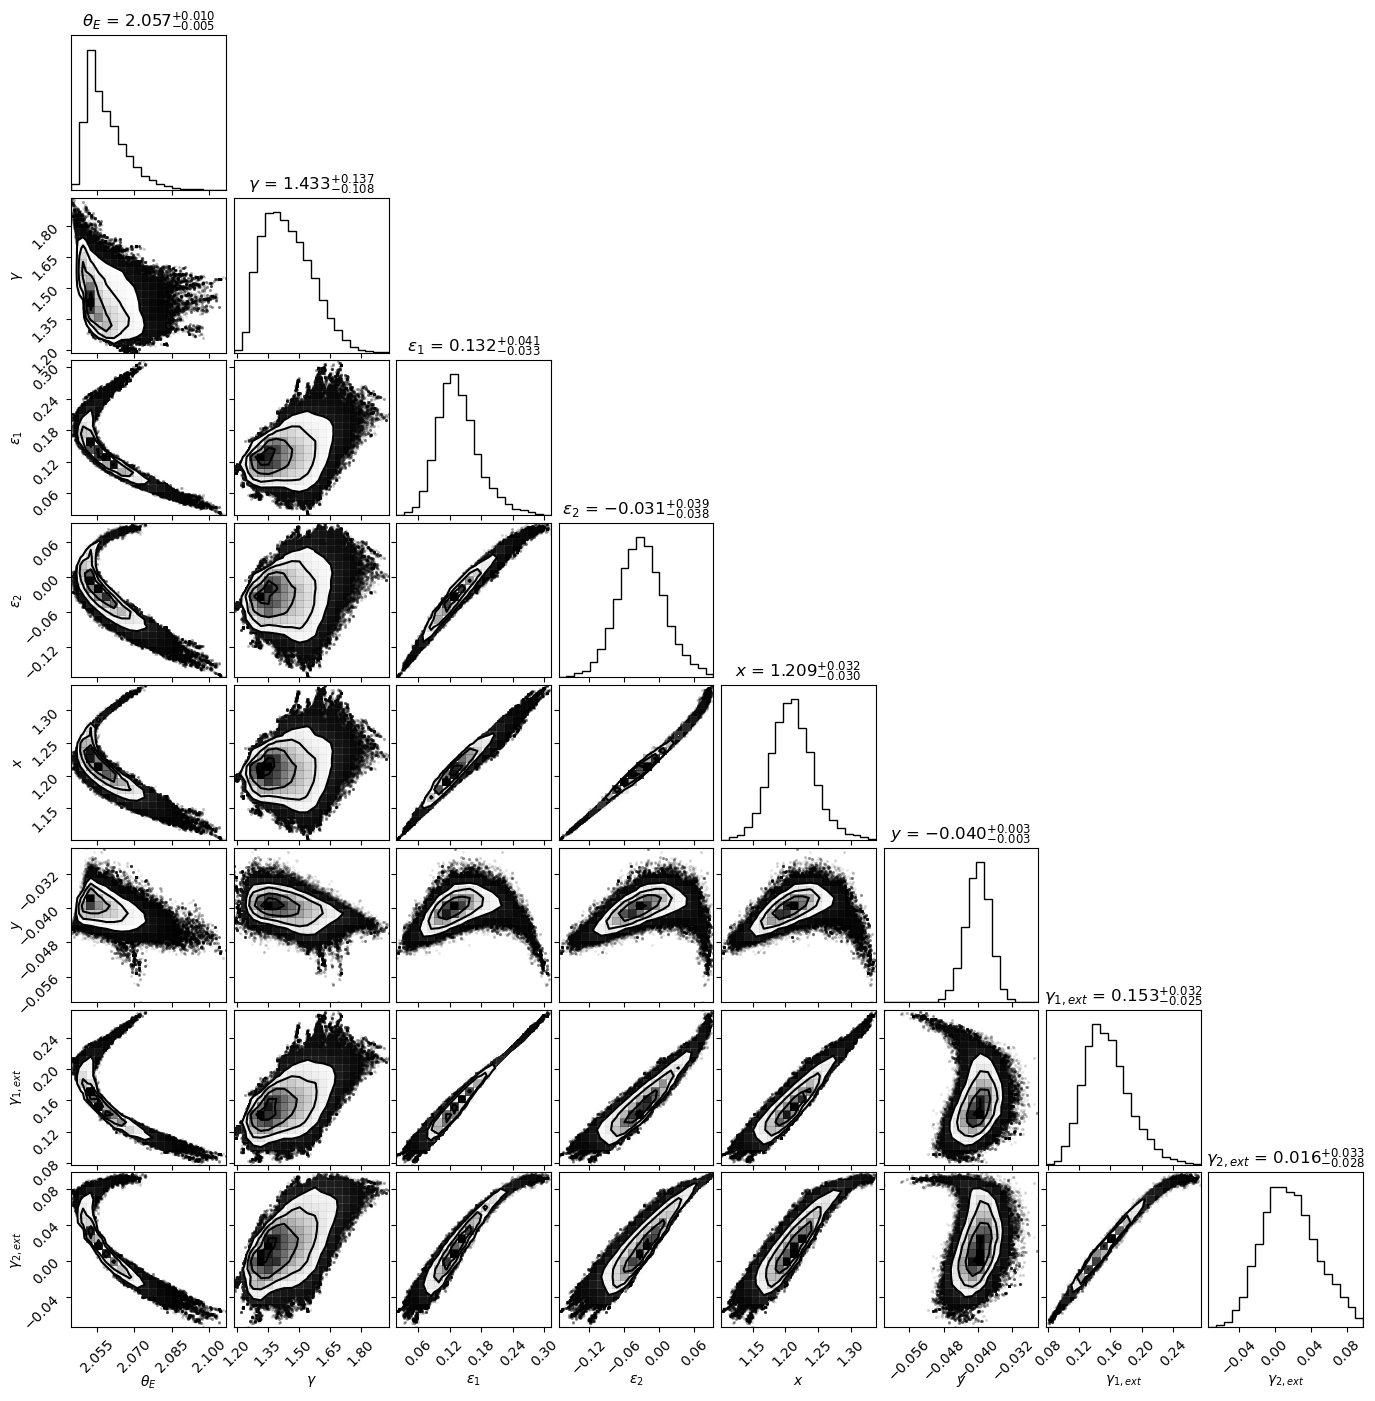

Parameter  |     Mean |   Median
--------------------------------
theta_E    |   2.0588 |   2.0567
gamma      |   1.4466 |   1.4333
e1         |   0.1365 |   0.1320
e2         |  -0.0297 |  -0.0305
center_x   |   1.2107 |   1.2094
center_y   |  -0.0401 |  -0.0400
gamma1     |   0.1564 |   0.1531
gamma2     |   0.0175 |   0.0155


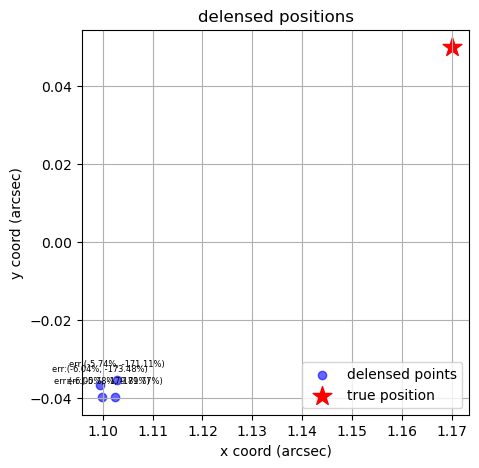

self.prob_model_output
 - theta_E   :    2.056689
   gamma     :    1.433340
   e2        :   -0.030518
   e1        :    0.132004
   center_y  :   -0.040033
   center_x  :    1.209423
 - gamma2    :    0.015513
   gamma1    :    0.153101


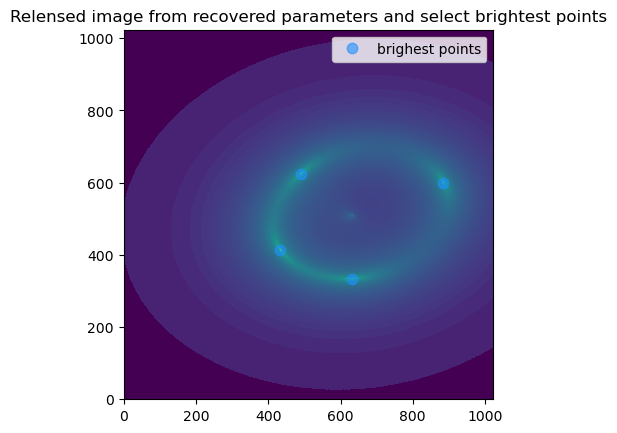

Brighest points reshaped into x, y:

x: [[-0.78123224]
 [-0.21396822]
 [ 3.70712   ]
 [ 1.2091678 ]]

y: [[-0.99022424]
 [ 1.1195998 ]
 [ 0.87079984]
 [-1.7764323 ]]

Kwargs lens
 - theta_E   :    2.056689
   gamma     :    1.433340
   e1        :    0.132004
   e2        :   -0.030518
   center_x  :    1.209423
   center_y  :   -0.040033
 - gamma1    :    0.153101
   gamma2    :    0.015513


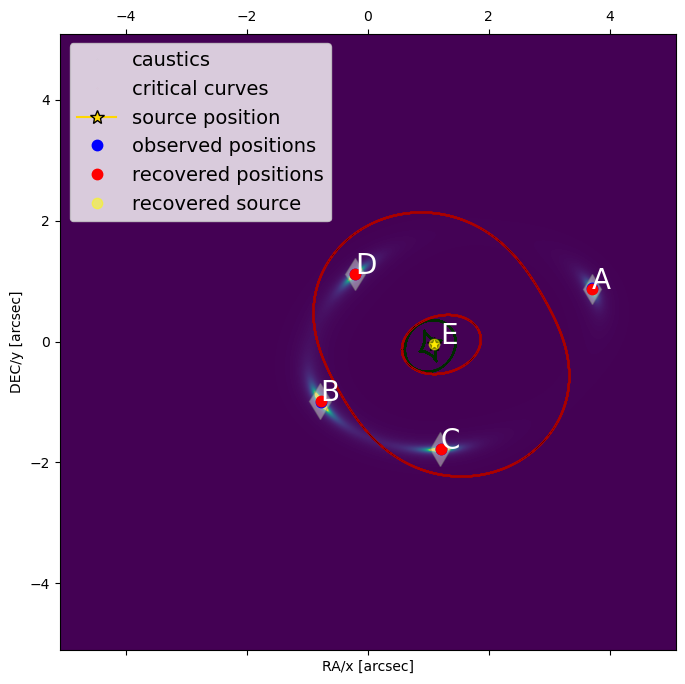


----- flux ratio errors -----
la mag del input tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)

loss terms (in observed positions):
 [[0.00595703]
 [0.00682629]
 [0.00955181]
 [0.00066255]
 [0.00229018]
 [0.0012425 ]]

flux ratios observed:
 [[3.450143 ]
 [4.337319 ]
 [6.858542 ]
 [1.2571418]
 [1.9879007]
 [1.5812861]]

flux ratios recovered (in observed positions):
 [[0.41587618]
 [0.8602904 ]
 [1.993243  ]
 [2.0686216 ]
 [4.792876  ]
 [2.316942  ]]

relative errors (in observed positions):
flux1/flux2: 87.95%
flux1/flux3: 80.17%
flux1/flux4: 70.94%
flux2/flux3: 64.55%
flux2/flux4: 141.10%
flux3/flux4: 46.52%

observed_magnifications SN Zicky: tf.Tensor([0.5199572  0.2799297  0.24966455 0.19854167], shape=(4,), dtype=float32)

Predicted magnifications (in recovered positions). The ordering may have changed:
 [[ 34.09217 ]
 [-23.254232]
 [ 16.483936]
 [-24.232061]]

Predicted magnifications (in observed positions):
 [[-22.429829]
 [ 34.99692 ]
 [-24.332

In [15]:
# resolution
supersample = 1
num_pix = data.shape[0]
delta_pix = pixscale

# Modeling
observed_data = [[x_arcsec, y_arcsec], flux_truth_test]

lens_prior_chosen = lens_prior_norm
prior = tfd.JointDistributionSequential([lens_prior_chosen,])
# prob model without observed image
prob_model = ForwardProbModel(prior, 0, background_rms=bkg_rms, exp_time=exptime)

# Uniform prior
prior_uniform = tfd.JointDistributionSequential([lens_prior_uniform,])
prob_model_uniform = ForwardProbModel(prior_uniform, 0, background_rms=bkg_rms, exp_time=exptime)
losses_list = []
for wd in [1e2, 1e4]:#[1, 1e2, 1e4]: #, 1e1, 1e2]: #, 5e2, 1e3, 5e3]:
  for wf in [1e2]:#[1, 1e2, 1e4]: #, 5e2, 1e3, 5e3]:
    print('\n    ============== weight_dist = %.2e | weight_flux = %.2e ==============\n'%(wd,wf))
    analysis = LensModelAnalysis(delta_pix=pixscale, num_pix=num_pix, weight_dist=wd, weight_flux=wf, truth_test=truth_test,
                                prob_model=prob_model,
                                prior=prior,
                                #lens_prior = lens_prior,
                                phys_model = phys_model,
                                prob_model_uniform=prob_model_uniform,
                                observed_data = observed_data, simulation = False, flux_ratios = True)
    losses = analysis.run_map(n_map = 500, n_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-1,
                                              'end_learning_rate': 1e-4, 'power': 1.0},
                    uniform_comparison = False,
                    track_loss_all = True,
                    test_results_dict = {'relative_errors': False, 
                                         'plot_loss': True, 
                                         'flux_ratio_error': False, 
                                         'delensed_positions': False,},
                    return_loss = True)
    losses_list.append(losses)
    analysis.run_vi(n_vi = 500, num_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-2,
                                            'end_learning_rate': 1e-4,
                                            'power': 1.0})
    samples_phys = analysis.run_hmc(n_hmc=500, num_burnin_steps=200, num_results=1000, method = "adaptative",
                                     init_eps = 0.5, init_l = 3, max_leapfrog_steps = 100)
      

In [61]:
from matplotlib._pylab_helpers import Gcf

open_figs = [manager.canvas.figure for manager in Gcf.get_all_fig_managers()]
print(open_figs)

[]


- keep playing with different weights, learning rates and so to test results of ELBO loss,
- then run HMC too and compare results

- learning rate has to be fixed to avoid sudden crash at the end

- remove extra map with uniform prior

ELBO loss smooth plot with
```
n_map = 500, n_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-1,
                                              'end_learning_rate': 5e-3, 'power': 1.0}
```
```
n_vi = 500, num_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-5,
                                            'end_learning_rate': 4e-2,
                                            'power': 1.0}
```
- $w_d = $ 1, 10, 100 & $w_f=0$. Goes down from $\sim 70$ to $\sim 20$.
- $w_f>0$ $(w_f=0.1,\, 1, \, 10)$ more noisy but does not break down with SVI, **breaks down with HMC**

In [37]:
reload(src.flux_ratios_pipeline_funcs)
from src.flux_ratios_pipeline_funcs import *

flux_ratios_pipeline_funcs.py version: 0.2.4
